In [32]:
import pandas as pd

In [33]:
df = pd.read_csv('watson_healthcare_modified.csv')
df.head(4)

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1313919,41,No,Travel_Rarely,1102,Cardiology,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1200302,49,No,Travel_Frequently,279,Maternity,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,1060315,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,1272912,33,No,Travel_Frequently,1392,Maternity,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0


In [34]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['EducationField'] = df['EducationField'].map({'Other': 0, 'Life Sciences': 1, 'Medical': 2, 'Marketing': 3, 'Technical Degree': 4, 'Human Resources': 5})
df['is_other_JobRole'] = (df['JobRole'] == 'Other').astype(int)
df['JobRole'] = df['JobRole'].map({'Other': 0, 'Nurse': 1,'Therapist': 2, 'Administrative': 3, 'Admin': 4})

In [35]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [39]:
travel_frequency = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'] # 0.0 = Non-Travel, 1.0 = Travel_Rarely, 2.0 = Travel_Frequently
marital_status = ['Single','Married', 'Divorced'] # 0.0 = Single, 1.0 = Married, 2.0 = Divorced

In [40]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='error').set_output(transform='pandas')
oe_travel = OrdinalEncoder(categories=[travel_frequency])
oe_marital_status = OrdinalEncoder(categories= [marital_status])

In [41]:
df['BusinessTravel'] = oe_travel.fit_transform(df[['BusinessTravel']])
df['MaritalStatus'] = oe_marital_status.fit_transform(df[['MaritalStatus']])

In [42]:
enc_department = ohe.fit_transform(X_train[['Department']])
df = pd.concat([df, enc_department], axis=1).drop(columns=['Department'])

In [43]:
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(1340, 35)

(336, 35)

(1340,)

(336,)

In [44]:
dropping_columns = ['EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
X_train.drop(dropping_columns, axis=1, inplace=True)
X_train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,is_other_JobRole
417,40,Travel_Rarely,1398,Cardiology,2,4,1,3,0,79,...,4,0,21,2,3,20,15,1,12,0
243,40,Travel_Rarely,1300,Maternity,24,2,4,1,1,62,...,1,2,9,3,3,9,8,4,7,1
1628,25,Travel_Rarely,622,Cardiology,13,1,2,2,1,40,...,3,0,7,1,3,7,4,0,6,1
454,33,Travel_Rarely,922,Maternity,1,5,2,1,0,95,...,3,1,10,2,3,6,1,0,5,0
1532,39,Travel_Frequently,505,Maternity,2,4,4,3,0,64,...,4,0,20,1,3,19,6,11,8,1


In [45]:
X_test.drop(dropping_columns, axis=1, inplace=True)
X_test.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,is_other_JobRole
1260,42,Travel_Rarely,855,Maternity,12,3,2,2,1,57,...,2,3,7,6,2,5,3,0,4,0
709,29,Travel_Rarely,906,Maternity,10,3,1,4,0,92,...,3,0,3,5,3,0,0,0,0,1
261,38,Non-Travel,1327,Cardiology,2,2,1,4,1,39,...,4,1,13,0,3,8,7,7,5,0
107,25,Travel_Rarely,240,Cardiology,5,3,3,3,1,46,...,4,0,6,1,3,6,4,0,3,0
1639,29,Travel_Rarely,352,Neurology,6,1,2,4,1,87,...,4,0,1,3,3,1,0,0,0,1


In [46]:
df.drop(dropping_columns, axis=1, inplace=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,is_other_JobRole,Department_Cardiology,Department_Maternity,Department_Neurology
0,41,0,1.0,1102,1,2,1,2,0,94,...,0,1,6,4,0,5,0,1.0,0.0,0.0
1,49,0,2.0,279,8,1,1,3,1,61,...,3,3,10,7,1,7,1,NaN,NaN,NaN
2,37,1,1.0,1373,2,2,0,4,1,92,...,3,3,0,0,0,0,0,0.0,1.0,0.0
3,33,0,2.0,1392,3,4,1,4,0,56,...,3,3,8,7,3,0,1,0.0,1.0,0.0
4,27,0,1.0,591,2,1,2,1,1,40,...,3,3,2,2,2,2,0,0.0,1.0,0.0


In [47]:
df['BusinessTravel'].unique()

array([1., 2., 0.])

In [48]:
(df.dtypes == 'object').any()

np.False_

In [49]:
(df.dtypes == 'object').any()

np.False_

### Feature Extraction

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
corr_y = df.corr()['Attrition'].drop('Attrition')

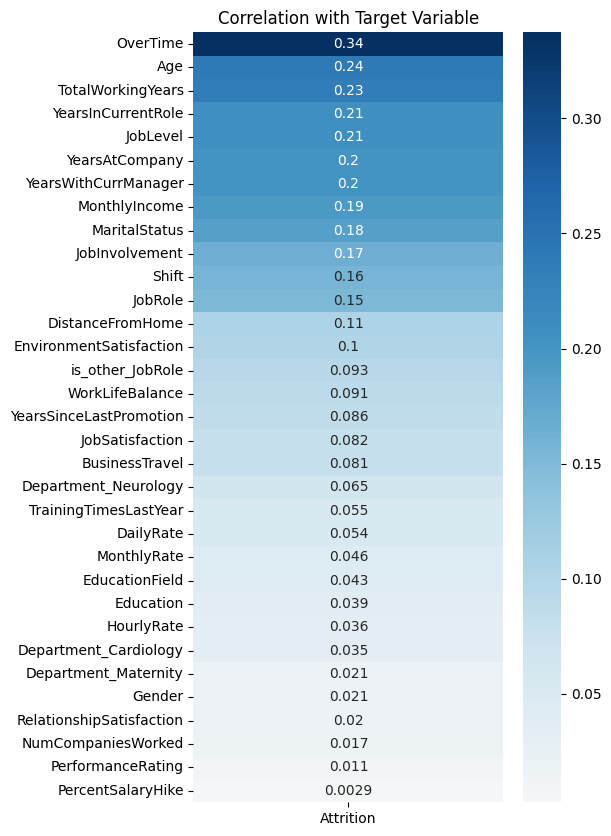

In [52]:
target_corr = (df.corr()[['Attrition']].drop('Attrition').abs()).sort_values(by='Attrition', ascending=False)

plt.figure(figsize=(5, 10))
sns.heatmap(target_corr, annot=True, cmap='RdBu', center=0)
plt.title('Correlation with Target Variable')
plt.show()

In [53]:
feature_extracted_dataset = df[['Age', 'JobLevel', 'OverTime', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'JobRole', 'Attrition']]
feature_extracted_dataset.sample(7)

,Age,JobLevel,OverTime,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,JobRole,Attrition
884,42,3,1,20,1,0,0,3,0
1076,39,3,0,9,2,0,2,2,0
271,47,3,1,10,10,7,9,0,1
966,48,3,0,11,10,9,8,2,0
420,29,3,0,10,10,2,7,3,0
145,30,1,0,8,3,2,2,0,0
1115,26,1,0,1,1,0,0,0,0


In [54]:
feature_extracted_dataset.shape

(1676, 9)

In [55]:
top_features = corr_y.abs().sort_values(ascending=False)
print(top_features[:7])

OverTime                0.337383
Age                     0.239984
TotalWorkingYears       0.234182
YearsInCurrentRole      0.207891
JobLevel                0.207634
YearsAtCompany          0.201373
YearsWithCurrManager    0.201087
Name: Attrition, dtype: float64


In [56]:
feature_extracted_dataset.to_csv('Feature_extracted_train_data.csv', index=False)